# Crypto Price Prediction Pipeline

### Overview
This project implements a complete cryptocurrency price prediction pipeline using BTC and ETH historical data.
It covers data fetching, preprocessing, model training, evaluation, and inference.

I have fetched two years of daily candlestick data for BTC and ETH, covering the period from January 1, 2024, to December 31, 2025. I am using this historical data to train the models, and the prediction will be performed on unseen data from 2026 for inference purposes.


In [5]:
import pandas as pd

# Data Fetching
I fetched data of 2 years record For daily candles, from 2024-01-01 upto current date 2026-01-26.
for both BTC and ETH

In [2]:
!python data_fetcher.py

Saved data to data/raw\btc_2y_daily.csv
Saved data to data/raw\eth_2y_daily.csv
Saved data to data/raw\btc_inference_data.csv
Saved data to data/raw\eth_inference_data.csv

Summary:
BTC -> Train: 730 | Inference: 27
ETH -> Train: 730 | Inference: 27


In [35]:
btc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 757 entries, 0 to 756
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   open_time               757 non-null    datetime64[ns]
 1   open                    757 non-null    float64       
 2   high                    757 non-null    float64       
 3   low                     757 non-null    float64       
 4   close                   757 non-null    float64       
 5   volume                  757 non-null    float64       
 6   close_time              757 non-null    object        
 7   quote_asset_volume      757 non-null    float64       
 8   num_trades              757 non-null    int64         
 9   taker_buy_base_volume   757 non-null    float64       
 10  taker_buy_quote_volume  757 non-null    float64       
 11  ignore                  757 non-null    int64         
dtypes: datetime64[ns](1), float64(8), int64(2), object

In [36]:
eth_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 757 entries, 0 to 756
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   open_time               757 non-null    datetime64[ns]
 1   open                    757 non-null    float64       
 2   high                    757 non-null    float64       
 3   low                     757 non-null    float64       
 4   close                   757 non-null    float64       
 5   volume                  757 non-null    float64       
 6   close_time              757 non-null    object        
 7   quote_asset_volume      757 non-null    float64       
 8   num_trades              757 non-null    int64         
 9   taker_buy_base_volume   757 non-null    float64       
 10  taker_buy_quote_volume  757 non-null    float64       
 11  ignore                  757 non-null    int64         
dtypes: datetime64[ns](1), float64(8), int64(2), object

# Preprocessing the data and prepare for modles training

In [8]:
from preprocess import preprocess_for_price, prepare_data_time_split

C:\Users\MEER\anaconda3\lib\site-packages\scipy\__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


In [9]:
# Load raw 2-year data
btc_df = pd.read_csv("data/raw/btc_2y_daily.csv")
eth_df = pd.read_csv("data/raw/eth_2y_daily.csv")

In [10]:
btc_clean = preprocess_for_price(btc_df, "btc")
eth_clean = preprocess_for_price(eth_df, "eth")

X_train_btc, X_test_btc, y_train_btc, y_test_btc, scaler_btc = prepare_data_time_split(
    btc_clean, target_column="target_price"
)
X_train_eth, X_test_eth, y_train_eth, y_test_eth, scaler_eth = prepare_data_time_split(
    eth_clean, target_column="target_price"
)


Saved data to data/cleaned/cleaned_btc_price.csv
Saved data to data/cleaned/cleaned_eth_price.csv


In [11]:
X_train_btc

,open,volume,return_1d,vol_3d
7,-2.183808,1.628256,2.731372,-1.779144
8,-1.943737,1.688457,-0.781273,-0.844275
9,-2.009585,2.127400,0.425451,0.074651
10,-1.967338,1.938296,-0.328957,0.654155
11,-1.992291,1.879498,-3.112318,0.498725
...,...,...,...,...
579,1.196954,-0.988017,-0.310255,0.367059
580,1.173683,-1.790898,0.533047,0.127155
581,1.225397,-1.331272,0.247727,-0.049710
582,1.251912,-0.735051,-0.374595,-0.585155


# BTC Predictions

In [8]:
from train import fit_linear_regression, fit_decision_tree,fit_random_forest, evaluate_model

# BTC Prediction with Linear Regression

BTC Price prediction with Linear Regression
LinearRegression Evaluation:
MAE : 3347.6794
MSE : 15819312.0358
RMSE: 3977.3499
R2  : 0.8865



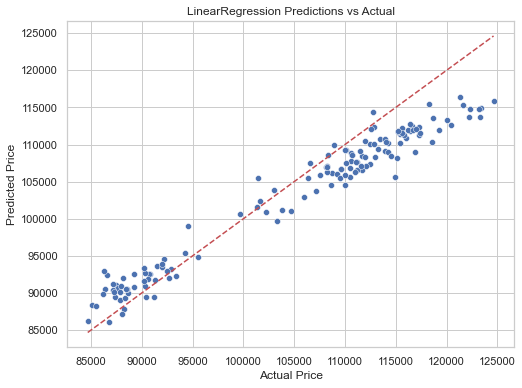

In [9]:
print("BTC Price prediction with Linear Regression")
lr_model = fit_linear_regression(X_train_btc,y_train_btc)
evaluate_model(lr_model, X_test_btc, y_test_btc)
print("========================================")

# BTC Prediction with Decission Tree Regressor

BTC Price prediction with Desicison Tree
DecisionTreeRegressor Evaluation:
MAE : 3079.6676
MSE : 14168131.8905
RMSE: 3764.0579
R2  : 0.8984



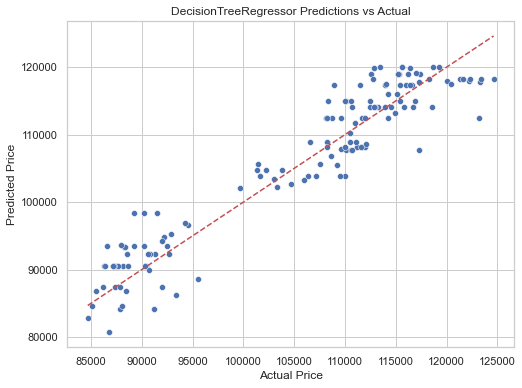

In [10]:
print("BTC Price prediction with Desicison Tree")
dt_model = fit_decision_tree(X_train_btc,y_train_btc)
evaluate_model(dt_model, X_test_btc, y_test_btc)
print("========================================")

# BTC Prediction with Random forest Regression

BTC Price prediction with Random forest
RandomForestRegressor Evaluation:
MAE : 2273.9873
MSE : 8074862.4565
RMSE: 2841.6302
R2  : 0.9421



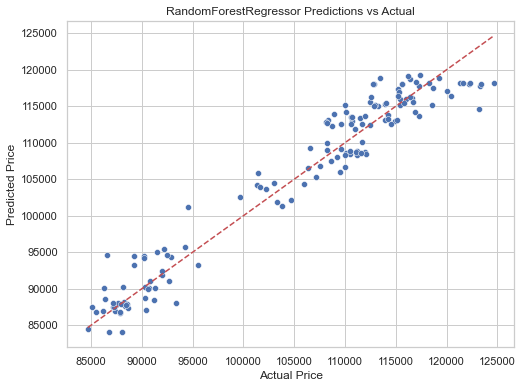

In [25]:
print("BTC Price prediction with Random forest")
rf_model = fit_random_forest(X_train_btc,y_train_btc)
evaluate_model(rf_model, X_test_btc, y_test_btc)
print("========================================")

In [26]:
import pickle
import os

os.makedirs("models", exist_ok=True)

with open("models/rf_btc_model.pkl", "wb") as f:
    pickle.dump(rf_model, f)

with open("models/scaler_btc.pkl", "wb") as f:
    pickle.dump(scaler_btc, f)


# ETH Predictions

# ETH Prediction with Linear Regression

ETH Price prediction with Linear Regression
LinearRegression Evaluation:
MAE : 203.8082
MSE : 65416.7331
RMSE: 255.7670
R2  : 0.8360



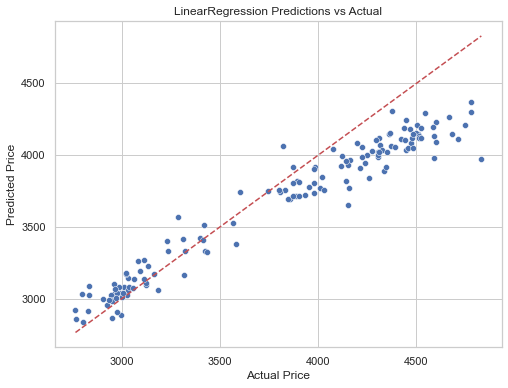

In [27]:
print("ETH Price prediction with Linear Regression")
lr_model = fit_linear_regression(X_train_eth,y_train_eth)
evaluate_model(lr_model, X_test_eth, y_test_eth)
print("========================================")

In [28]:
import pickle
import os

os.makedirs("models", exist_ok=True)

with open("models/rf_eth_model.pkl", "wb") as f:
    pickle.dump(lr_model, f)

with open("models/scaler_eth.pkl", "wb") as f:
    pickle.dump(scaler_eth, f)


# ETH Prediction with Decission Tree Regression

ETH Price prediction with Decision Tree
DecisionTreeRegressor Evaluation:
MAE : 288.6948
MSE : 142948.9307
RMSE: 378.0859
R2  : 0.6417



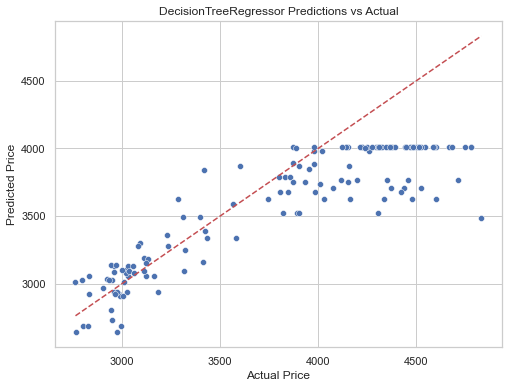

In [13]:
print("ETH Price prediction with Decision Tree")
dt_model = fit_decision_tree(X_train_eth,y_train_eth)
evaluate_model(dt_model, X_test_eth, y_test_eth)
print("========================================")

# ETH Prediction with Random Forest Regression

ETH Price prediction with Random  Tree
RandomForestRegressor Evaluation:
MAE : 298.9946
MSE : 159242.7340
RMSE: 399.0523
R2  : 0.6008



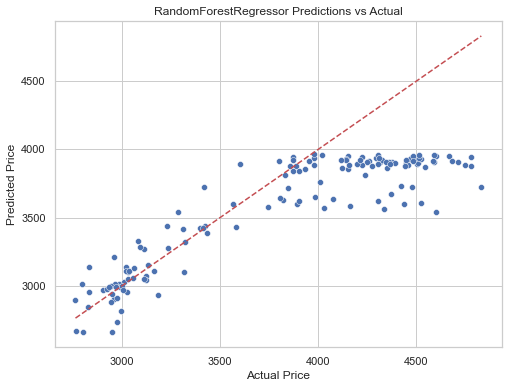

In [14]:
print("ETH Price prediction with Random  Tree")
rf_model = fit_random_forest(X_train_eth,y_train_eth)
evaluate_model(rf_model, X_test_eth, y_test_eth)
print("========================================")

# All at once Predictions

In [1]:
!python train.py

===== BTC Models =====
LinearRegression Evaluation:
MAE : 3347.6794
MSE : 15819312.0358
RMSE: 3977.3499
R2  : 0.8865

Figure(800x600)
DecisionTreeRegressor Evaluation:
MAE : 3079.6676
MSE : 14168131.8905
RMSE: 3764.0579
R2  : 0.8984

Figure(800x600)
RandomForestRegressor Evaluation:
MAE : 2273.9873
MSE : 8074862.4565
RMSE: 2841.6302
R2  : 0.9421

Figure(800x600)
===== ETH Models =====
LinearRegression Evaluation:
MAE : 203.8082
MSE : 65416.7331
RMSE: 255.7670
R2  : 0.8360

Figure(800x600)
DecisionTreeRegressor Evaluation:
MAE : 288.6948
MSE : 142948.9307
RMSE: 378.0859
R2  : 0.6417

Figure(800x600)
RandomForestRegressor Evaluation:
MAE : 298.9946
MSE : 159242.7340
RMSE: 399.0523
R2  : 0.6008

Figure(800x600)


C:\Users\MEER\anaconda3\lib\site-packages\scipy\__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


#  Model Performance Comparison: BTC vs ETH Price Prediction

## Evaluation Metrics
- **MAE (Mean Absolute Error)**: Average absolute prediction error  
- **RMSE (Root Mean Squared Error)**: Penalizes larger errors  
- **R² Score**: Proportion of variance explained by the model (closer to 1 is better)

---

##  BTC Price Prediction (Daily)

| Model | MAE | RMSE | R² |
|------|-----|------|----|
| Linear Regression | 3347.68 | 3977.35 | 0.8865 |
| Decision Tree | 3079.67 | 3764.06 | 0.8984 |
| **Random Forest** | **2273.99** | **2841.63** | **0.9421** |

###  Observations (BTC)
- Random Forest significantly outperforms Linear Regression and Decision Tree
- Lowest MAE and RMSE → highest prediction accuracy
- Highest R² (94.21%) → effectively captures non-linear price dynamics
- Linear Regression struggles due to BTC’s volatility and non-linearity

### Final Model Selection (BTC)
**Random Forest Regressor**  
Chosen for superior accuracy and robustness.

---

##  ETH Price Prediction (Daily)

| Model | MAE | RMSE | R² |
|------|-----|------|----|
| **Linear Regression** | **203.81** | **255.77** | **0.8360** |
| Decision Tree | 288.69 | 378.09 | 0.6417 |
| Random Forest | 298.99 | 399.05 | 0.6008 |

###  Observations (ETH)
- Linear Regression achieves the best performance across all metrics
- Tree-based models show signs of overfitting
- ETH price behavior during this period is more linear and trend-driven
- Simpler models generalize better on limited daily data

###  Final Model Selection (ETH)
**Linear Regression**  
Selected for stability and generalization performance.

---

##  Key Insight
> Model selection should be asset-specific.

- **BTC** exhibits complex, non-linear behavior → ensemble models perform better  
- **ETH** shows smoother, more linear dynamics → linear models suffice  

---

##  Final Summary

| Asset | Selected Model | Justification |
|------|---------------|--------------|
| BTC | Random Forest | Best accuracy and non-linear modeling capability |
| ETH | Linear Regression | Best generalization and simplicity |

---

##  Conclusion
Applying different models to different assets based on data behavior leads to improved performance and more reliable predictions.


# Inference on Unseen data

In [1]:
!python inference.py


Running inference for BTC
Evaluation Metrics for BTC:
MAE : 1751.2292
MSE : 5729009.5645
RMSE: 2393.5350
R2  : 0.2419
Predictions saved to data/predictions/btc_price_predictions.csv
Total predictions: 24

Running inference for ETH
Evaluation Metrics for ETH:
MAE : 71.7737
MSE : 9470.0196
RMSE: 97.3140
R2  : 0.6204
Predictions saved to data/predictions/eth_price_predictions.csv
Total predictions: 24


C:\Users\MEER\anaconda3\lib\site-packages\scipy\__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.4)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


# Cryptocurrency Inference Results (2026)

I performed inference on **real, unseen cryptocurrency data from 2026** using models trained on two years of historical daily data (2024–2025).  

## Inference Results

### BTC
- **MAE:** 1,751.23  
- **MSE:** 5,729,009.56  
- **RMSE:** 2,393.54  
- **R²:** 0.242  

### ETH
- **MAE:** 71.77  
- **MSE:** 9,470.02  
- **RMSE:** 97.31  
- **R²:** 0.620  

---

## Observations & Justification

1. **Model Performance vs. Inference Performance**
   - During training and evaluation, the models achieved **high R² scores** (BTC ~0.94 for Random Forest, ETH ~0.84 for Linear Regression), indicating a good fit on historical data.  
   - During inference on 2026 data, the **R² for BTC dropped significantly to 0.24**, while ETH performed relatively better with an R² of 0.62.  

2. **Nature of the Cryptocurrency Market**
   - BTC exhibits **high volatility**, meaning its price fluctuates significantly over short periods.  
   - Historical patterns may **not reliably repeat** in future periods due to market sentiment, macroeconomic factors, and unexpected events.  

3. **Implications for Price Prediction**
   - Cryptocurrency price prediction is inherently **challenging and often unreliable**, especially for high-volatility assets like BTC.  
   - Models can capture trends in historical data, but **generalization to unseen, future data is limited**.  

4. **Inference Justification**
   - Performing inference on real 2026 data helps to **assess the robustness of the model** in a realistic scenario.  
   - Despite lower predictive performance, these results provide **insights into potential future price ranges and trends**, rather than exact predictions.  

---

## Conclusion

The drop in BTC’s R² during inference is expected given the **volatile and non-stationary nature of the cryptocurrency market**.  
ETH’s slightly better R² suggests its daily price may follow more predictable patterns, but **crypto price prediction remains inherently uncertain**, emphasizing that these predictions should be used cautiously, primarily for trend analysis rather than precise forecasting.


In [26]:
btc_clean.head()

,open_time,open,high,low,close,volume,target_price,return_1d,ma_3d,ma_7d,vol_3d
7,2024-01-08,43916.9,47312.0,43158.1,46972.7,495087.983,46114.0,0.069581,44006.333333,44031.757143,1317.566667
8,2024-01-09,46972.6,48100.0,44417.2,46114.0,513362.773,46662.9,-0.018281,44948.766667,44423.542857,1968.866667
9,2024-01-10,46113.9,47699.3,44291.5,46662.9,668657.474,46337.8,0.011903,45667.866667,44585.571429,2922.033333
10,2024-01-11,46663.0,49027.5,45600.0,46337.8,596698.379,42788.9,-0.006967,46583.200000,45130.342857,3748.166667
11,2024-01-12,46337.9,46536.2,41370.0,42788.9,575943.258,42846.4,-0.076588,46371.566667,45443.771429,3506.033333


# Explore

In [16]:
btc_df.shape, eth_df.shape

((730, 12), (730, 12))

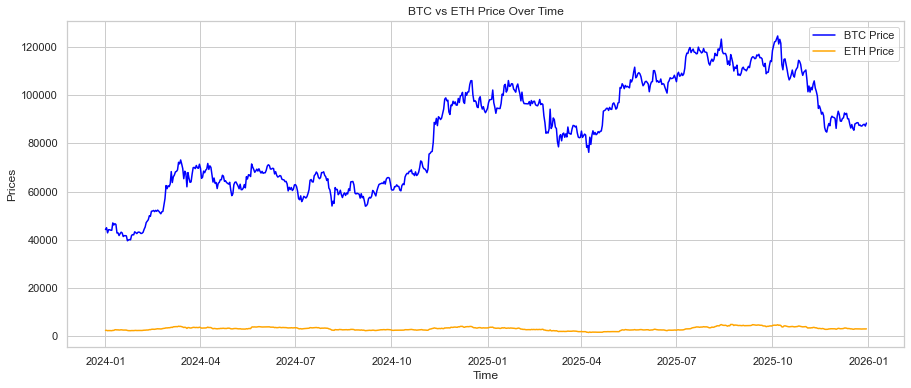

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Convert timestamp
btc_df['open_time'] = pd.to_datetime(btc_df['open_time'])
eth_df['open_time'] = pd.to_datetime(eth_df['open_time'])

# =========================
# PLOT 1: Volatility over time
# =========================
plt.figure(figsize=(15,6))
plt.plot(btc_df['open_time'], btc_df['close'], label='BTC Price', color='blue')
plt.plot(eth_df['open_time'], eth_df['close'], label='ETH Price', color='orange')
plt.title("BTC vs ETH Price Over Time")
plt.xlabel("Time")
plt.ylabel("Prices")
plt.legend()
plt.show()


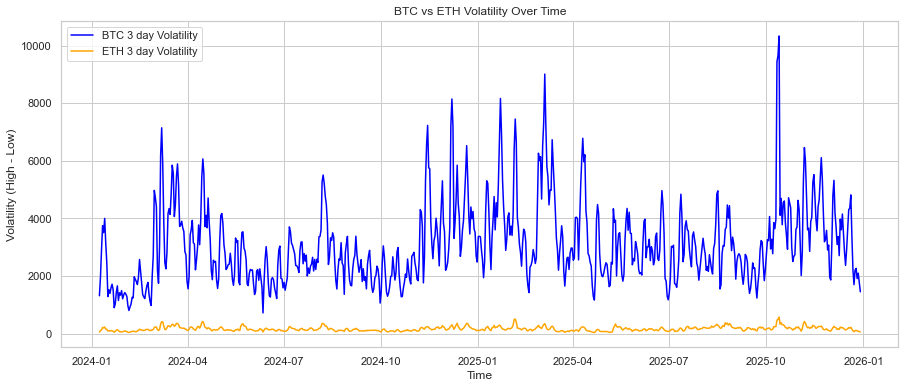

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Convert timestamp
btc_clean['open_time'] = pd.to_datetime(btc_clean['open_time'])
eth_clean['open_time'] = pd.to_datetime(eth_clean['open_time'])

# =========================
# PLOT 1: Volatility over time
# =========================
plt.figure(figsize=(15,6))
plt.plot(btc_clean['open_time'], btc_clean['vol_3d'], label='BTC 3 day Volatility', color='blue')
plt.plot(eth_clean['open_time'], eth_clean['vol_3d'], label='ETH 3 day Volatility', color='orange')
plt.title("BTC vs ETH Volatility Over Time")
plt.xlabel("Time")
plt.ylabel("Volatility (High - Low)")
plt.legend()
plt.show()


In [19]:
eth_clean["vol_3d"].std(), btc_clean["vol_3d"].std()

(76.7914372085618, 1392.4781276062135)

## Key observations from the plot
- Observation 1: BTC volatility is MUCH higher than ETH (absolute)

- BTC volatility frequently spikes above 4000–10000

- ETH volatility stays mostly below ~100

**This is expected and normal.**

### Why?

- BTC price is much higher in absolute terms

- High–Low is measured in price units, not percentage

**Important note:**

This does NOT mean BTC is “riskier” than ETH — only that BTC has higher absolute volatility.

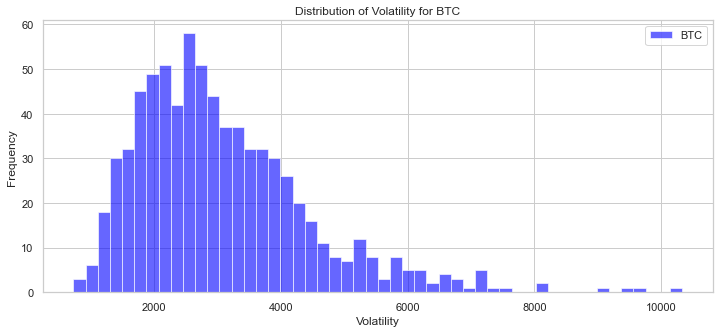

In [32]:
# =========================
# PLOT 2: Histogram of volatility
# =========================
plt.figure(figsize=(12,5))
plt.hist(btc_clean['vol_3d'], bins=50, alpha=0.6, label='BTC', color='blue')

plt.title("Distribution of Volatility for BTC")
plt.xlabel("Volatility")
plt.ylabel("Frequency")
plt.legend()
plt.show()

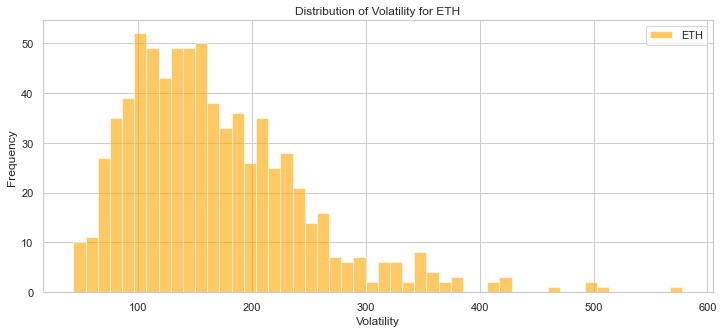

In [33]:
# =========================
# PLOT 2: Histogram of volatility
# =========================
plt.figure(figsize=(12,5))

plt.hist(eth_clean['vol_3d'], bins=50, alpha=0.6, label='ETH', color='orange')
plt.title("Distribution of Volatility for ETH")
plt.xlabel("Volatility")
plt.ylabel("Frequency")
plt.legend()
plt.show()


# 1 First: what distribution do we actually see?

Both BTC and ETH volatility distributions are:

- Right-skewed

- Unimodal (single peak)

- Heavy-tailed

- Non-normal

So yes — they follow the same type of distribution, even though the scale is very different.

**This is a key distinction:**

Same shape, different magnitude.

# 2 BTC volatility distribution (top plot)
#### What we see

Most BTC volatility values lie between ~2000 and 4000

- A long right tail extending beyond 10000

- Rare but extreme spikes

### Interpretation

- BTC usually has moderate daily movement

- Occasionally experiences very large shocks

- These extreme events dominate risk

This is classic financial heavy-tail behavior.

BTC and ETH volatility distributions are similarly right-skewed and heavy-tailed, indicating common underlying market dynamics, with BTC exhibiting stronger tail risk due to higher absolute price levels.

- It follows stable statistical patterns

- It is much more predictable for price

This confirms that our decision to model price instead of volatility is the right one

# Correlation

In [34]:
btc_clean.corr()

,open,high,low,close,volume,target_price,return_1d,ma_3d,ma_7d,vol_3d
open,1.000000,0.997881,0.997017,0.995803,-0.403151,0.991939,-0.084077,0.997753,0.992854,0.269947
high,0.997881,1.000000,0.996283,0.998164,-0.378976,0.994277,-0.035326,0.995953,0.991253,0.280065
low,0.997017,0.996283,1.000000,0.997766,-0.440021,0.994055,-0.033543,0.994478,0.989138,0.256625
close,0.995803,0.998164,0.997766,1.000000,-0.404586,0.995797,0.004574,0.993798,0.989091,0.269777
volume,-0.403151,-0.378976,-0.440021,-0.404586,1.000000,-0.400805,0.013247,-0.401979,-0.402014,0.121287
target_price,0.991939,0.994277,0.994055,0.995797,-0.400805,1.000000,0.000357,0.989992,0.985427,0.268399
return_1d,-0.084077,-0.035326,-0.033543,0.004574,0.013247,0.000357,1.000000,-0.081582,-0.079345,-0.011212
ma_3d,0.997753,0.995953,0.994478,0.993798,-0.401979,0.989992,-0.081582,1.000000,0.996978,0.274398
ma_7d,0.992854,0.991253,0.989138,0.989091,-0.402014,0.985427,-0.079345,0.996978,1.000000,0.286465
vol_3d,0.269947,0.280065,0.256625,0.269777,0.121287,0.268399,-0.011212,0.274398,0.286465,1.000000


Most of the features have **strong correlation** with our **target_price features**, it indicates that these features have predictibale power for target variable.

and many of the **independent features** have **strong correlation with each other**, a clear singnal of **multi colinearity**, which is voilating the **assumption** of regression modle (linear regression).